In [1]:
import pandas as pd
import numpy as np

In [2]:
ratings = pd.read_csv("ratings_small.csv")

In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [6]:
!pip install scikit-surprise

In [5]:
!pip install "numpy<2"

In [7]:
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate

In [8]:
reader = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))

In [9]:
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [10]:
print(f"Rating scale: {ratings['rating'].min()} to {ratings['rating'].max()}")

Rating scale: 0.5 to 5.0


In [11]:
from surprise import KNNBasic

sim_options = {
    "name": "cosine",
    "user_based": True,
}

user_based_cf = KNNBasic(sim_options=sim_options)

In [12]:
results_user_cf = cross_validate(user_based_cf, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9947  0.9977  0.9950  0.9920  0.9924  0.9944  0.0020  
MAE (testset)     0.7687  0.7701  0.7673  0.7669  0.7658  0.7678  0.0015  
Fit time          0.14    0.14    0.13    0.13    0.14    0.14    0.00    
Test time         0.99    0.95    1.09    0.95    1.12    1.02    0.07    


In [13]:
avg_rmse_user = results_user_cf['test_rmse'].mean()
avg_mae_user = results_user_cf['test_mae'].mean()

In [14]:
sim_options_item = {
    'name': 'cosine',
    'user_based': False  # This is the key difference!
}

In [15]:
item_based_cf = KNNBasic(sim_options=sim_options_item)

In [16]:
results_item_cf = cross_validate(item_based_cf, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9894  1.0007  0.9950  0.9914  1.0012  0.9956  0.0048  
MAE (testset)     0.7706  0.7773  0.7720  0.7748  0.7787  0.7747  0.0031  
Fit time          4.72    4.73    4.73    4.80    4.73    4.74    0.03    
Test time         4.18    4.39    4.35    4.31    4.24    4.29    0.08    


In [17]:
avg_rmse_item = results_item_cf['test_rmse'].mean()
avg_mae_item = results_item_cf['test_mae'].mean()

In [18]:
from surprise import SVD

In [19]:
pmf = SVD()

In [20]:
results_pmf = cross_validate(pmf, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8887  0.8992  0.8995  0.9000  0.8992  0.8973  0.0043  
MAE (testset)     0.6851  0.6926  0.6926  0.6915  0.6903  0.6904  0.0028  
Fit time          0.98    1.07    1.03    1.09    1.05    1.04    0.04    
Test time         0.10    0.10    0.23    0.10    0.10    0.13    0.05    


In [21]:
avg_rmse_pmf = results_pmf['test_rmse'].mean()
avg_mae_pmf = results_pmf['test_mae'].mean()

In [22]:
print("\nRMSE Comparison:")
print(f"User-based CF:  {avg_rmse_user:.4f}")
print(f"Item-based CF:  {avg_rmse_item:.4f}")
print(f"PMF (SVD):      {avg_rmse_pmf:.4f}")

print("\nMAE Comparison:")
print(f"User-based CF:  {avg_mae_user:.4f}")
print(f"Item-based CF:  {avg_mae_item:.4f}")
print(f"PMF (SVD):      {avg_mae_pmf:.4f}")


RMSE Comparison:
User-based CF:  0.9944
Item-based CF:  0.9956
PMF (SVD):      0.8973

MAE Comparison:
User-based CF:  0.7678
Item-based CF:  0.7747
PMF (SVD):      0.6904


In [23]:
best_rmse_model = min([('User-based CF', avg_rmse_user),
                       ('Item-based CF', avg_rmse_item),
                       ('PMF', avg_rmse_pmf)], key=lambda x: x[1])

best_mae_model = min([('User-based CF', avg_mae_user),
                      ('Item-based CF', avg_mae_item),
                      ('PMF', avg_mae_pmf)], key=lambda x: x[1])

In [24]:
print(f"Best model by RMSE: {best_rmse_model[0]} ({best_rmse_model[1]:.4f})")
print(f"Best model by MAE:  {best_mae_model[0]} ({best_mae_model[1]:.4f})")

Best model by RMSE: PMF (0.8973)
Best model by MAE:  PMF (0.6904)


In [25]:
similarities = ['cosine', 'msd', 'pearson']
user_cf_results = {}

In [27]:
for sim in similarities:
    print(f"\nTesting User-based CF with {sim} similarity...")

    sim_options = {
        'name': sim,
        'user_based': True
    }

    algo = KNNBasic(sim_options=sim_options)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    user_cf_results[sim] = {
        'rmse': results['test_rmse'].mean(),
        'mae': results['test_mae'].mean()
    }

    print(f"  RMSE: {user_cf_results[sim]['rmse']:.4f}")
    print(f"  MAE:  {user_cf_results[sim]['mae']:.4f}")


Testing User-based CF with cosine similarity...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9941
  MAE:  0.7679

Testing User-based CF with msd similarity...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9684
  MAE:  0.7446

Testing User-based CF with pearson similarity...
Computing the pearson similarity matrix...
Done co

In [28]:
item_cf_results = {}

In [29]:
for sim in similarities:
    print(f"\nTesting Item-based CF with {sim} similarity...")

    sim_options = {
        'name': sim,
        'user_based': False
    }

    algo = KNNBasic(sim_options=sim_options)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    item_cf_results[sim] = {
        'rmse': results['test_rmse'].mean(),
        'mae': results['test_mae'].mean()
    }

    print(f"  RMSE: {item_cf_results[sim]['rmse']:.4f}")
    print(f"  MAE:  {item_cf_results[sim]['mae']:.4f}")


Testing Item-based CF with cosine similarity...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9943
  MAE:  0.7739

Testing Item-based CF with msd similarity...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
  RMSE: 0.9355
  MAE:  0.7218

Testing Item-based CF with pearson similarity...
Computing the pearson similarity matrix...
Done co

In [30]:
import matplotlib.pyplot as plt

sims = ['cosine', 'msd', 'pearson']
user_rmse = [user_cf_results[sim]['rmse'] for sim in sims]
user_mae = [user_cf_results[sim]['mae'] for sim in sims]
item_rmse = [item_cf_results[sim]['rmse'] for sim in sims]
item_mae = [item_cf_results[sim]['mae'] for sim in sims]

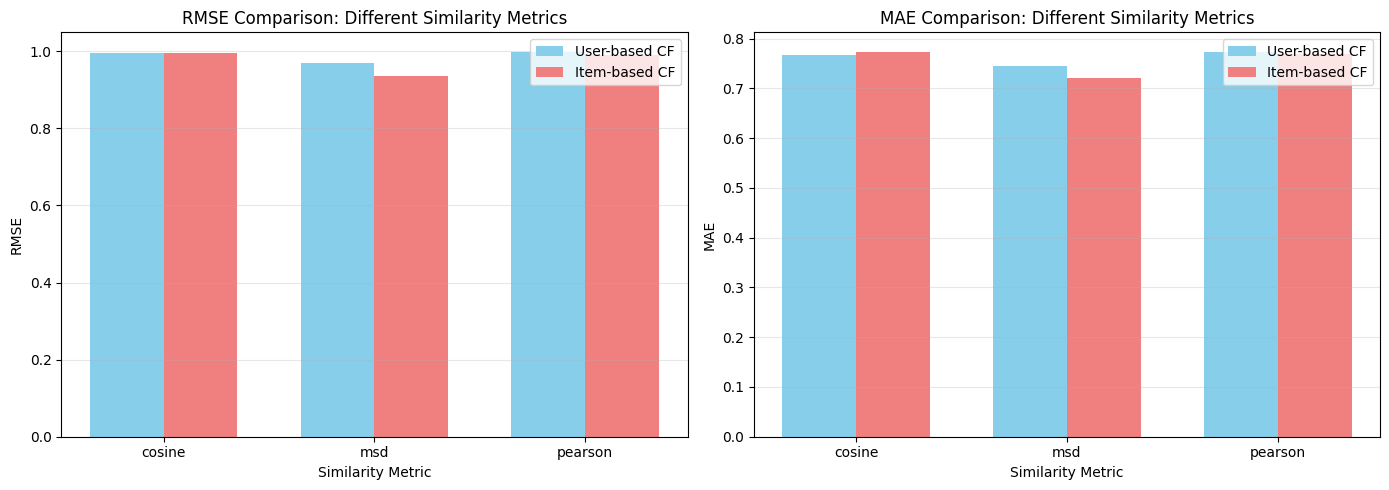

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE comparison
x = range(len(sims))
width = 0.35

axes[0].bar([i - width/2 for i in x], user_rmse, width, label='User-based CF', color='skyblue')
axes[0].bar([i + width/2 for i in x], item_rmse, width, label='Item-based CF', color='lightcoral')
axes[0].set_xlabel('Similarity Metric')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE Comparison: Different Similarity Metrics')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sims)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Plot MAE comparison
axes[1].bar([i - width/2 for i in x], user_mae, width, label='User-based CF', color='skyblue')
axes[1].bar([i + width/2 for i in x], item_mae, width, label='Item-based CF', color='lightcoral')
axes[1].set_xlabel('Similarity Metric')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE Comparison: Different Similarity Metrics')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sims)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [33]:
k_values = [5, 10, 20, 30, 40, 50]
user_cf_k_results = {}

In [34]:
for k in k_values:
    print(f"\nTesting User-based CF with K={k}...")

    sim_options = {
        'name': 'cosine',
        'user_based': True
    }

    algo = KNNBasic(k=k, sim_options=sim_options)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    user_cf_k_results[k] = {
        'rmse': results['test_rmse'].mean(),
        'mae': results['test_mae'].mean()
    }

    print(f"  RMSE: {user_cf_k_results[k]['rmse']:.4f}")
    print(f"  MAE:  {user_cf_k_results[k]['mae']:.4f}")


Testing User-based CF with K=5...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 1.0430
  MAE:  0.8052

Testing User-based CF with K=10...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 1.0116
  MAE:  0.7794

Testing User-based CF with K=20...
Computing the cosine similarity matrix...
Done computing similarity matri

In [35]:
item_cf_k_results = {}

for k in k_values:
    print(f"\nTesting Item-based CF with K={k}...")

    sim_options = {
        'name': 'cosine',
        'user_based': False
    }

    algo = KNNBasic(k=k, sim_options=sim_options)
    results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

    item_cf_k_results[k] = {
        'rmse': results['test_rmse'].mean(),
        'mae': results['test_mae'].mean()
    }

    print(f"  RMSE: {item_cf_k_results[k]['rmse']:.4f}")
    print(f"  MAE:  {item_cf_k_results[k]['mae']:.4f}")


Testing Item-based CF with K=5...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 1.1008
  MAE:  0.8590

Testing Item-based CF with K=10...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
  RMSE: 1.0544
  MAE:  0.8249

Testing Item-based CF with K=20...
Computing the cosine similarity matrix...
Done computing similarity matri

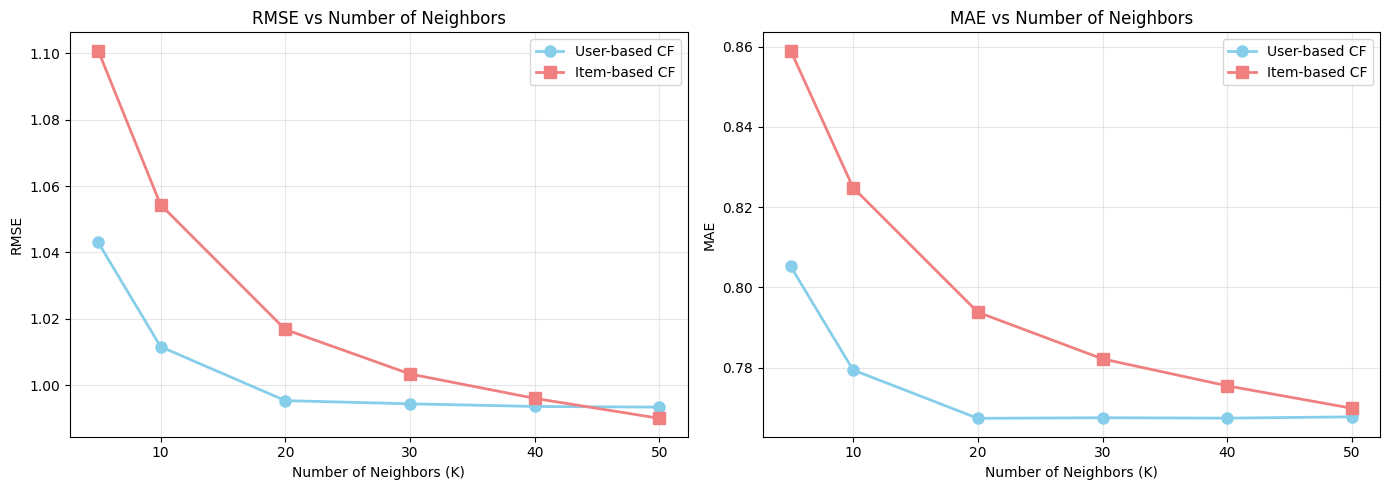

In [36]:
# Prepare data for plotting
k_list = list(k_values)
user_rmse_k = [user_cf_k_results[k]['rmse'] for k in k_list]
user_mae_k = [user_cf_k_results[k]['mae'] for k in k_list]
item_rmse_k = [item_cf_k_results[k]['rmse'] for k in k_list]
item_mae_k = [item_cf_k_results[k]['mae'] for k in k_list]

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot RMSE vs K
axes[0].plot(k_list, user_rmse_k, marker='o', label='User-based CF', linewidth=2, markersize=8, color='skyblue')
axes[0].plot(k_list, item_rmse_k, marker='s', label='Item-based CF', linewidth=2, markersize=8, color='lightcoral')
axes[0].set_xlabel('Number of Neighbors (K)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs Number of Neighbors')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot MAE vs K
axes[1].plot(k_list, user_mae_k, marker='o', label='User-based CF', linewidth=2, markersize=8, color='skyblue')
axes[1].plot(k_list, item_mae_k, marker='s', label='Item-based CF', linewidth=2, markersize=8, color='lightcoral')
axes[1].set_xlabel('Number of Neighbors (K)')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE vs Number of Neighbors')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Find the best K for User-based CF
best_k_user_rmse = min(user_cf_k_results.items(), key=lambda x: x[1]['rmse'])
best_k_user_mae = min(user_cf_k_results.items(), key=lambda x: x[1]['mae'])

# Find the best K for Item-based CF
best_k_item_rmse = min(item_cf_k_results.items(), key=lambda x: x[1]['rmse'])
best_k_item_mae = min(item_cf_k_results.items(), key=lambda x: x[1]['mae'])

In [38]:
print("\nUser-based Collaborative Filtering:")
print(f"  Best K by RMSE: K={best_k_user_rmse[0]} (RMSE={best_k_user_rmse[1]['rmse']:.4f})")
print(f"  Best K by MAE:  K={best_k_user_mae[0]} (MAE={best_k_user_mae[1]['mae']:.4f})")


User-based Collaborative Filtering:
  Best K by RMSE: K=50 (RMSE=0.9934)
  Best K by MAE:  K=20 (MAE=0.7673)


In [39]:
print("\nItem-based Collaborative Filtering:")
print(f"  Best K by RMSE: K={best_k_item_rmse[0]} (RMSE={best_k_item_rmse[1]['rmse']:.4f})")
print(f"  Best K by MAE:  K={best_k_item_mae[0]} (MAE={best_k_item_mae[1]['mae']:.4f})")


Item-based Collaborative Filtering:
  Best K by RMSE: K=50 (RMSE=0.9900)
  Best K by MAE:  K=50 (MAE=0.7698)


In [40]:
if best_k_user_rmse[0] == best_k_item_rmse[0]:
    print(f"✓ Both methods have the same best K: {best_k_user_rmse[0]}")
else:
    print(f"✗ Different best K values:")
    print(f"  User-based CF best K: {best_k_user_rmse[0]}")
    print(f"  Item-based CF best K: {best_k_item_rmse[0]}")

✓ Both methods have the same best K: 50


In [41]:
print("\n1. BASIC ALGORITHM COMPARISON (Part c & d):")
print("-" * 70)
print(f"{'Algorithm':<25} {'RMSE':<15} {'MAE':<15}")
print("-" * 70)
print(f"{'User-based CF':<25} {avg_rmse_user:<15.4f} {avg_mae_user:<15.4f}")
print(f"{'Item-based CF':<25} {avg_rmse_item:<15.4f} {avg_mae_item:<15.4f}")
print(f"{'PMF (SVD)':<25} {avg_rmse_pmf:<15.4f} {avg_mae_pmf:<15.4f}")
print("-" * 70)
print(f"Best Model: {best_rmse_model[0]}")


1. BASIC ALGORITHM COMPARISON (Part c & d):
----------------------------------------------------------------------
Algorithm                 RMSE            MAE            
----------------------------------------------------------------------
User-based CF             0.9944          0.7678         
Item-based CF             0.9956          0.7747         
PMF (SVD)                 0.8973          0.6904         
----------------------------------------------------------------------
Best Model: PMF


In [42]:
print("\n2. SIMILARITY METRIC COMPARISON (Part e):")
print("-" * 70)
print("User-based CF:")
for sim in similarities:
    print(f"  {sim:<10} - RMSE: {user_cf_results[sim]['rmse']:.4f}, MAE: {user_cf_results[sim]['mae']:.4f}")

print("\nItem-based CF:")
for sim in similarities:
    print(f"  {sim:<10} - RMSE: {item_cf_results[sim]['rmse']:.4f}, MAE: {item_cf_results[sim]['mae']:.4f}")


2. SIMILARITY METRIC COMPARISON (Part e):
----------------------------------------------------------------------
User-based CF:
  cosine     - RMSE: 0.9941, MAE: 0.7679
  msd        - RMSE: 0.9684, MAE: 0.7446
  pearson    - RMSE: 0.9990, MAE: 0.7736

Item-based CF:
  cosine     - RMSE: 0.9943, MAE: 0.7739
  msd        - RMSE: 0.9355, MAE: 0.7218
  pearson    - RMSE: 0.9895, MAE: 0.7683


In [43]:
print("\n3. OPTIMAL K VALUES (Part f & g):")
print("-" * 70)
print(f"User-based CF - Best K: {best_k_user_rmse[0]} (RMSE: {best_k_user_rmse[1]['rmse']:.4f})")
print(f"Item-based CF - Best K: {best_k_item_rmse[0]} (RMSE: {best_k_item_rmse[1]['rmse']:.4f})")
print(f"\nAre optimal K values the same? {'Yes' if best_k_user_rmse[0] == best_k_item_rmse[0] else 'No'}")


3. OPTIMAL K VALUES (Part f & g):
----------------------------------------------------------------------
User-based CF - Best K: 50 (RMSE: 0.9934)
Item-based CF - Best K: 50 (RMSE: 0.9900)

Are optimal K values the same? Yes
